
# Distribución de $\hat\beta$ en regresión lineal — Introducción intuitiva

Este cuaderno busca que entiendas **qué es cada objeto** ($X$, $X'$, $X'X$, etc.) antes de simular nada.  
Supón que estás viendo regresión múltiple por **primera vez**: vamos paso a paso.

---

# 1) ¿Qué es una muestra? (las $n$-uplas)

Una muestra de tamaño $n$ en regresión NO es solo un vector de $Y$.  
Cada observación es una **n-upla**:

$$
(Y_i,\ X_{i1},\ X_{i2})
$$

Ejemplo con $n=3$ observaciones:

| i | $Y_i$ | $X_{i1}$ | $X_{i2}$ |
|---|---|---|---|
|1| $y_1$ | 0 | 1 |
|2| $y_2$ | 1 | 0 |
|3| $y_3$ | 2 | 1 |

👉 **Cada fila es UNA observación completa.**  
👉 El tamaño de la muestra $n$ = número de filas.

---

# 2) Regresión univariable → multivariable (intuición)

## Caso univariable

$$
Y_i=\beta_0+\beta_1 X_i+\varepsilon_i
$$

La matriz $X$ tiene solo dos columnas:

$$
X=
\begin{bmatrix}
1 & X_1\\
1 & X_2\\
\vdots & \vdots\\
1 & X_n
\end{bmatrix}
$$

- Primera columna: unos → intercepto.
- Segunda columna: valores del predictor.

---

## Caso multivariable (lo que usamos aquí)

$$
Y_i=\beta_0+\beta_1 X_{i1}+\beta_2 X_{i2}+\varepsilon_i
$$

Ahora cada observación tiene **dos variables explicativas**, por eso $X$ tiene 3 columnas:

$$
X=
\begin{bmatrix}
1 & X_{11} & X_{12}\\
1 & X_{21} & X_{22}\\
\vdots & \vdots & \vdots\\
1 & X_{n1} & X_{n2}
\end{bmatrix}
$$

### Intuición clave

- **Filas** = observaciones.
- **Columnas** = variables explicativas.
- Número de columnas = número de parámetros en $\beta$.

---

# 3) Ejemplo mini (n=3) — viendo cada pieza claramente

Supón la muestra:

$$
( y_1,0,1),\quad (y_2,1,0),\quad (y_3,2,1)
$$

Entonces:

## Vector respuesta

$$
Y=
\begin{bmatrix}
y_1\\
y_2\\
y_3
\end{bmatrix}
$$

👉 Tiene $n$ filas porque hay $n$ observaciones.

---

## Matriz de diseño

Cada fila corresponde EXACTAMENTE a una observación:

$$
X=
\begin{bmatrix}
1 & 0 & 1\\
1 & 1 & 0\\
1 & 2 & 1
\end{bmatrix}
$$

Interpretación fila por fila:

- Fila 1 = observación 1 → intercepto=1, $X_{11}=0$, $X_{12}=1$
- Fila 2 = observación 2 → intercepto=1, $X_{21}=1$, $X_{22}=0$
- Fila 3 = observación 3 → intercepto=1, $X_{31}=2$, $X_{32}=1$

👉 **El tamaño de la muestra se ve en el número de filas.**  
👉 **El número de regresores se ve en el número de columnas (menos la columna de unos).**

---

# 4) ¿Qué hace la transpuesta $X'$?

La transpuesta intercambia filas por columnas:

$$
X'=
\begin{bmatrix}
1 & 1 & 1\\
0 & 1 & 2\\
1 & 0 & 1
\end{bmatrix}
$$

Intuición:

- Cada fila de $X'$ corresponde a **una variable**:
  - fila 1 → intercepto
  - fila 2 → predictor 1
  - fila 3 → predictor 2

---

# 5) ¿Qué es $X'X$? (la geometría del problema)

$$
X'X=
\begin{bmatrix}
3 & 3 & 2\\
3 & 5 & 2\\
2 & 2 & 2
\end{bmatrix}
$$

Cada entrada es un producto interno:

- esquina superior izquierda = $n$.
- diagonal = “energía” o variabilidad de cada predictor.
- fuera de diagonal = relación entre predictores.

👉 Si los predictores están muy correlacionados → $(X'X)^{-1}$ crece → varianzas grandes.

---

# 6) ¿Qué es $X'Y$?

$$
X'Y=
\begin{bmatrix}
\sum Y_i\\
\sum X_{i1}Y_i\\
\sum X_{i2}Y_i
\end{bmatrix}
$$

Intuición:

- resume cómo se relaciona $Y$ con cada columna de $X$.
- es un vector de **covariaciones acumuladas**.

---

# 7) Estimador OLS — visión intuitiva

$$
\hat\beta=(X'X)^{-1}X'Y
$$

Lectura conceptual:

1. $X'Y$ mide cómo $Y$ se alinea con cada predictor.
2. $(X'X)^{-1}$ corrige por escalas y correlaciones.
3. Resultado → pendientes e intercepto.

---

# 8) Distribución de $\hat\beta$

Si

$$
\varepsilon\mid X\sim\mathcal N(0,\sigma^2 I_n),
$$

entonces

$$
\hat\beta\mid X\sim \mathcal N\big(\beta,\ \sigma^2(X'X)^{-1}\big).
$$

Mensaje fundamental para entender TODO el notebook:

- La precisión de $\hat\beta$ depende de **cómo están distribuidos los datos en $X$**.
- No depende solo de $n$.
- Por eso $\sigma^2/n$ NO es la varianza general de una pendiente.


Matriz var-cov empírica de (beta1_hat, beta2_hat):
[[ 0.0243048  -0.01900135]
 [-0.01900135  0.0243552 ]]


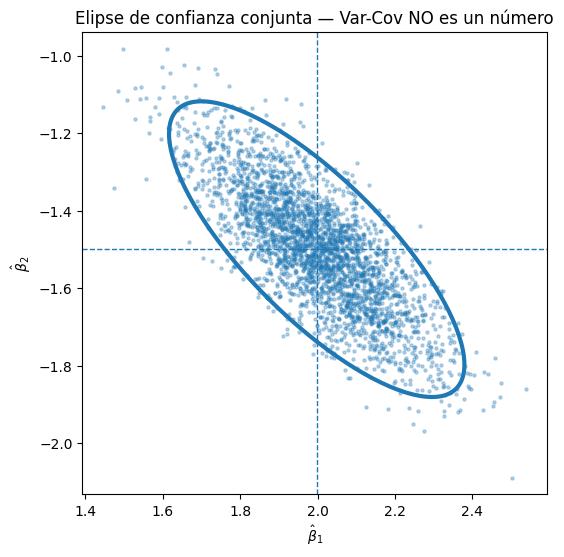

In [2]:
# @title
# ==========================================================
# Visualización intuitiva: matriz Var-Cov como ELIPSE
# ==========================================================
# Idea:
# Si Var(beta_hat) = sigma^2 (X'X)^(-1)
# entonces (beta1_hat, beta2_hat) tienen una distribución
# conjunta normal -> nube elíptica.
#
# La forma y rotación de la elipse están dadas por
# la matriz var-covarianza.
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Simulación pequeña ----------
rng = np.random.default_rng(123)

n = 120
beta_true = np.array([1.0, 2.0, -1.5])
sigma = 1.0

# Generar regresores correlacionados
rho = 0.8
cov = [[1, rho],[rho,1]]
X12 = rng.multivariate_normal([0,0], cov, size=n)

x1 = X12[:,0]
x2 = X12[:,1]

X = np.column_stack([np.ones(n), x1, x2])

XtX_inv = np.linalg.inv(X.T @ X)

# ---------- 2) Generar muchas estimaciones beta_hat ----------
R = 3000
betas = np.zeros((R,3))

for r in range(R):
    eps = rng.normal(0, sigma, n)
    y = X @ beta_true + eps
    bhat = XtX_inv @ (X.T @ y)
    betas[r,:] = bhat

b1 = betas[:,1]
b2 = betas[:,2]

# ---------- 3) Var-cov empírica ----------
Sigma = np.cov(np.vstack([b1,b2]))
print("Matriz var-cov empírica de (beta1_hat, beta2_hat):")
print(Sigma)

# ---------- 4) Dibujar elipse ----------
vals, vecs = np.linalg.eigh(Sigma)

# ángulos para círculo unitario
t = np.linspace(0, 2*np.pi, 200)
circle = np.vstack([np.cos(t), np.sin(t)])

# transformar círculo -> elipse
ellipse = vecs @ np.diag(np.sqrt(vals*5.991)) @ circle
# 5.991 ~ cuantíl chi^2_2(0.95)

# ---------- 5) Plot ----------
plt.figure(figsize=(6,6))
plt.scatter(b1, b2, s=5, alpha=0.3)

mu1, mu2 = b1.mean(), b2.mean()
plt.plot(mu1 + ellipse[0], mu2 + ellipse[1], linewidth=3)

plt.axvline(mu1, linestyle="--", linewidth=1)
plt.axhline(mu2, linestyle="--", linewidth=1)

plt.xlabel(r"$\hat{\beta}_1$")
plt.ylabel(r"$\hat{\beta}_2$")
plt.title("Elipse de confianza conjunta — Var-Cov NO es un número")
plt.axis("equal")
plt.show()


Media: [0.99971409 1.99783959]
Var-Cov:
 [[0.00865997 0.00052938]
 [0.00052938 0.0243048 ]]


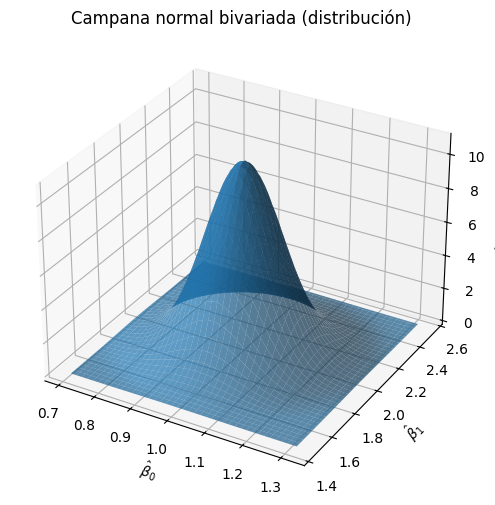

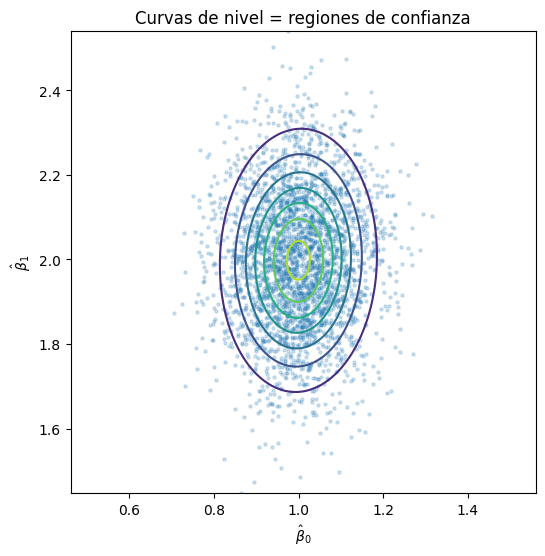

In [3]:
# @title
# ==========================================================
# CAMPANA BIVARIADA + REGION DE CONFIANZA (beta0, beta1)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------- Tomamos dos componentes ----------
b0 = betas[:,0]
b1 = betas[:,1]

# Media y covarianza empírica
mu = np.array([b0.mean(), b1.mean()])
Sigma = np.cov(np.vstack([b0,b1]))

print("Media:", mu)
print("Var-Cov:\n", Sigma)

# ---------- Grilla ----------
x = np.linspace(b0.min(), b0.max(), 80)
y = np.linspace(b1.min(), b1.max(), 80)
Xg, Yg = np.meshgrid(x, y)

pos = np.dstack((Xg, Yg))

# ---------- Densidad normal bivariada ----------
Sigma_inv = np.linalg.inv(Sigma)
det = np.linalg.det(Sigma)

Z = np.zeros_like(Xg)

for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        diff = pos[i,j] - mu
        Z[i,j] = np.exp(-0.5 * diff @ Sigma_inv @ diff)

Z = Z / (2*np.pi*np.sqrt(det))

# ==========================================================
# PLOT 3D — CAMPANA
# ==========================================================

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Xg, Yg, Z, alpha=0.7)

ax.set_xlabel(r"$\hat{\beta}_0$")
ax.set_ylabel(r"$\hat{\beta}_1$")
ax.set_zlabel("densidad")
ax.set_title("Campana normal bivariada (distribución)")

plt.show()


# ==========================================================
# PLOT 2D — CURVAS DE NIVEL = REGIONES DE CONFIANZA
# ==========================================================

plt.figure(figsize=(6,6))
plt.contour(Xg, Yg, Z, levels=8)
plt.scatter(b0, b1, s=5, alpha=0.2)

plt.xlabel(r"$\hat{\beta}_0$")
plt.ylabel(r"$\hat{\beta}_1$")
plt.title("Curvas de nivel = regiones de confianza")

plt.axis("equal")
plt.show()


In [4]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def make_design(n, rho, seed=0, center=True):
    rng = np.random.default_rng(seed)
    cov = np.array([[1.0, rho],[rho, 1.0]])
    X12 = rng.multivariate_normal([0.0, 0.0], cov, size=n)
    x1, x2 = X12[:,0], X12[:,1]
    if center:
        x1 = x1 - x1.mean()
        x2 = x2 - x2.mean()
    X = np.column_stack([np.ones(n), x1, x2])  # n x 3
    return X

def draw_ellipsoid(ax, mu, Sigma, conf=0.95, ngrid=40):
    # Elipsoide: (x-mu)' Sigma^{-1} (x-mu) = c
    # Para normal 3D, c = chi2_{3}(conf). Usamos aproximación tabulada común:
    # 0.95 -> 7.815, 0.90 -> 6.251, 0.99 -> 11.345
    chi2 = {0.90: 6.251, 0.95: 7.815, 0.99: 11.345}.get(conf, 7.815)
    c = chi2

    # Eigen-decomposición: Sigma = Q Λ Q'
    vals, vecs = np.linalg.eigh(Sigma)
    radii = np.sqrt(vals * c)  # semiejes

    # Parametrización esfera -> elipsoide
    u = np.linspace(0, 2*np.pi, ngrid)
    v = np.linspace(0, np.pi, ngrid)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    sphere = np.stack([xs, ys, zs], axis=0).reshape(3, -1)  # 3 x (ngrid^2)

    ell = (vecs @ (radii[:,None] * sphere)) + mu[:,None]    # 3 x M
    Xe, Ye, Ze = ell[0].reshape(ngrid, ngrid), ell[1].reshape(ngrid, ngrid), ell[2].reshape(ngrid, ngrid)

    ax.plot_wireframe(Xe, Ye, Ze, rstride=3, cstride=3, linewidth=1)

def sample_eps(rng, n, sigma, dist):
    if dist == "normal":
        return rng.normal(0.0, sigma, size=n)
    if dist == "t_df3":
        # t con df=3, var = 3/(3-2)=3. Escalamos para que sd = sigma.
        e = rng.standard_t(df=3, size=n)
        e = e / np.sqrt(3.0)  # ahora sd ~ 1
        return sigma * e
    if dist == "laplace":
        # Laplace(0,b) tiene var = 2b^2 => b = sigma/sqrt(2)
        b = sigma / np.sqrt(2.0)
        return rng.laplace(0.0, b, size=n)
    raise ValueError("dist no soportada")

def demo_R3(n=120, rho=0.7, sigma=1.0, R=2000, seed=1, conf=0.95, dist="normal", center_X=True):
    rng = np.random.default_rng(seed)

    beta_true = np.array([1.0, 2.0, -1.5])
    X = make_design(n, rho, seed=seed+10, center=center_X)
    XtX_inv = np.linalg.inv(X.T @ X)

    betas = np.zeros((R, 3))
    for r in range(R):
        eps = sample_eps(rng, n, sigma, dist)
        y = X @ beta_true + eps
        bhat = XtX_inv @ (X.T @ y)
        betas[r,:] = bhat

    mu_emp = betas.mean(axis=0)
    Sigma_emp = np.cov(betas.T)

    # Teoría (si errores normales): Var(beta_hat|X) = sigma^2 (X'X)^{-1}
    Sigma_theory = sigma**2 * XtX_inv

    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(betas[:,0], betas[:,1], betas[:,2], s=4, alpha=0.25)

    # Centro: media empírica (LGN sobre repeticiones)
    ax.scatter(mu_emp[0], mu_emp[1], mu_emp[2], s=80, marker="x")

    # Elipsoide: usa teoría si dist normal, si no usa empírico (para que igual se vea)
    Sigma_for_ellipsoid = Sigma_theory if dist == "normal" else Sigma_emp
    draw_ellipsoid(ax, mu_emp, Sigma_for_ellipsoid, conf=conf, ngrid=36)

    ax.set_xlabel(r"$\hat{\beta}_0$")
    ax.set_ylabel(r"$\hat{\beta}_1$")
    ax.set_zlabel(r"$\hat{\beta}_2$")
    ax.set_title("Nube de $(\\hat\\beta_0,\\hat\\beta_1,\\hat\\beta_2)$ y elipsoide normal")
    plt.show()

    print("Centro (media empírica):", np.round(mu_emp, 4))
    print("Beta verdadero:", beta_true)
    print("\nVar-Cov empírica (3x3):\n", np.round(Sigma_emp, 6))
    print("\nVar-Cov teórica sigma^2(X'X)^-1 (3x3) [válida exacta si eps normal]:\n", np.round(Sigma_theory, 6))

interact(
    demo_R3,
    n=IntSlider(120, min=30, max=500, step=10, description="n"),
    rho=FloatSlider(0.7, min=-0.9, max=0.9, step=0.05, description="rho"),
    sigma=FloatSlider(1.0, min=0.2, max=5.0, step=0.1, description="sigma"),
    R=IntSlider(2000, min=300, max=8000, step=200, description="R"),
    seed=IntSlider(1, min=0, max=999, step=1, description="seed"),
    conf=Dropdown(options=[0.90, 0.95, 0.99], value=0.95, description="conf"),
    dist=Dropdown(options=["normal", "t_df3", "laplace"], value="normal", description="eps"),
    center_X=Checkbox(True, description="Centrar X"),
);


interactive(children=(IntSlider(value=120, description='n', max=500, min=30, step=10), FloatSlider(value=0.7, …

In [5]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

def lgn_beta_hat(n=120, rho=0.7, sigma=1.0, R=2000, seed=0, dist="normal"):
    rng = np.random.default_rng(seed)
    beta_true = np.array([1.0, 2.0, -1.5])

    X = make_design(n, rho, seed=seed+100, center=True)
    XtX_inv = np.linalg.inv(X.T @ X)

    running_mean = np.zeros((R, 3))
    m = np.zeros(3)

    for r in range(R):
        eps = sample_eps(rng, n, sigma, dist)
        y = X @ beta_true + eps
        bhat = XtX_inv @ (X.T @ y)
        m = m + (bhat - m) / (r+1)        # promedio acumulado estable
        running_mean[r,:] = m

    # Plot: convergencia de las 3 componentes
    plt.figure()
    plt.plot(running_mean[:,0], linewidth=2)
    plt.plot(running_mean[:,1], linewidth=2)
    plt.plot(running_mean[:,2], linewidth=2)
    plt.axhline(beta_true[0], linestyle="--", linewidth=1)
    plt.axhline(beta_true[1], linestyle="--", linewidth=1)
    plt.axhline(beta_true[2], linestyle="--", linewidth=1)
    plt.title("LGN: promedio de $\\hat\\beta$ (sobre repeticiones R) converge a $\\beta$")
    plt.xlabel("R (repeticiones)")
    plt.ylabel("promedio acumulado")
    plt.show()

    print("Promedio final:", np.round(running_mean[-1], 4), " | Beta:", beta_true)

interact(
    lgn_beta_hat,
    n=IntSlider(120, min=30, max=400, step=10, description="n"),
    rho=FloatSlider(0.7, min=-0.9, max=0.9, step=0.05, description="rho"),
    sigma=FloatSlider(1.0, min=0.2, max=5.0, step=0.1, description="sigma"),
    R=IntSlider(2000, min=200, max=8000, step=200, description="R"),
    seed=IntSlider(0, min=0, max=999, step=1, description="seed"),
    dist=Dropdown(options=["normal", "t_df3", "laplace"], value="normal", description="eps"),
);


interactive(children=(IntSlider(value=120, description='n', max=400, min=30, step=10), FloatSlider(value=0.7, …

In [6]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox

def clt_beta_component(n=50, rho=0.7, sigma=1.0, R=4000, seed=0, dist="t_df3", comp="b1", show_normal=True):
    rng = np.random.default_rng(seed)
    beta_true = np.array([1.0, 2.0, -1.5])

    X = make_design(n, rho, seed=seed+200, center=True)
    XtX_inv = np.linalg.inv(X.T @ X)

    betas = np.zeros((R,3))
    for r in range(R):
        eps = sample_eps(rng, n, sigma, dist)
        y = X @ beta_true + eps
        betas[r,:] = XtX_inv @ (X.T @ y)

    idx = {"b0":0, "b1":1, "b2":2}[comp]
    vals = betas[:,idx]

    # Estandarización usando var empírica (para ver forma ~N(0,1))
    z = (vals - vals.mean()) / vals.std(ddof=1)

    plt.figure()
    plt.hist(z, bins=60, density=True, alpha=0.75)
    xs = np.linspace(z.min(), z.max(), 400)
    if show_normal:
        pdf = (1/np.sqrt(2*np.pi)) * np.exp(-0.5*xs**2)
        plt.plot(xs, pdf, linewidth=2)
    plt.title("TCL: componente estandarizada de $\\hat\\beta$ se acerca a $N(0,1)$ cuando n crece")
    plt.xlabel("z (estandarizado)")
    plt.ylabel("densidad")
    plt.show()

    print("n =", n, "| eps =", dist, "| comp =", comp)
    print("Asimetría empírica aprox:", float(((z - z.mean())**3).mean()))
    print("Curtosis empírica aprox:", float(((z - z.mean())**4).mean()))

interact(
    clt_beta_component,
    n=IntSlider(50, min=20, max=500, step=10, description="n"),
    rho=FloatSlider(0.7, min=-0.9, max=0.9, step=0.05, description="rho"),
    sigma=FloatSlider(1.0, min=0.2, max=5.0, step=0.1, description="sigma"),
    R=IntSlider(4000, min=500, max=12000, step=500, description="R"),
    seed=IntSlider(0, min=0, max=999, step=1, description="seed"),
    dist=Dropdown(options=["t_df3", "laplace", "normal"], value="t_df3", description="eps"),
    comp=Dropdown(options=["b0", "b1", "b2"], value="b1", description="comp"),
    show_normal=Checkbox(True, description="Curva N(0,1)"),
);


interactive(children=(IntSlider(value=50, description='n', max=500, min=20, step=10), FloatSlider(value=0.7, d…

In [8]:
# @title
# (Colab) habilitar widgets
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception as e:
    print("Si no estás en Colab, ignora esto:", e)

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider, Checkbox, Dropdown


## Controles

- $n$: tamaño de muestra  
- $\sigma$: desviación estándar del error  
- $\rho$: correlación entre $X_1$ y $X_2$ (para ver multicolinealidad)  
- $R$: número de simulaciones (réplicas) para aproximar la distribución de $\hat\beta$  


In [7]:
# @title
def simulate_betas(n=80, sigma=1.0, rho=0.3, R=2000, seed=123, center=True):
    rng = np.random.default_rng(seed)
    beta = np.array([1.0, 2.0, -1.5])  # (b0,b1,b2)

    # Generar X1, X2 con correlación rho (bivariada normal)
    cov = np.array([[1.0, rho],[rho, 1.0]])
    X12 = rng.multivariate_normal(mean=[0.0,0.0], cov=cov, size=n)
    x1 = X12[:,0]
    x2 = X12[:,1]

    if center:
        x1 = x1 - x1.mean()
        x2 = x2 - x2.mean()

    X = np.column_stack([np.ones(n), x1, x2])

    # Matriz (X'X)^-1 y var teórica
    XtX_inv = np.linalg.inv(X.T @ X)
    V_theory = sigma**2 * XtX_inv  # Var-cov teórica de hatbeta|X

    # Simular R veces
    betas_hat = np.empty((R, 3), float)
    for r in range(R):
        eps = rng.normal(0.0, sigma, size=n)
        y = X @ beta + eps
        bhat = XtX_inv @ (X.T @ y)
        betas_hat[r,:] = bhat

    return beta, betas_hat, V_theory, X

def plot_sampling(beta, betas_hat, V_theory, which="b1", bins=40, show_normal=True, compare_sigma2_over_n=True):
    idx = {"b0":0,"b1":1,"b2":2}[which]
    vals = betas_hat[:,idx]
    mu = beta[idx]
    var_true = V_theory[idx,idx]
    sd_true = np.sqrt(var_true)

    # "naive" comparación: sigma^2/n (solo para mostrar que NO es regla general)
    # Nota: para b0 tampoco aplica; igual lo calculamos para contraste visual.
    n = betas_hat.shape[0]  # esto es R, no usar

    # Para comparar sigma^2/n necesitamos sigma y n reales; los reconstruimos desde V_theory? No.
    # Mejor: recibimos sigma y n por fuera en la función envolvente.


In [9]:
# @title
def demo(n=80, sigma=1.0, rho=0.3, R=2000, seed=123, param="b1", bins=40,
         show_normal=True, show_naive=True, center_X=True):
    beta, betas_hat, V_theory, X = simulate_betas(
        n=n, sigma=sigma, rho=rho, R=R, seed=seed, center=center_X
    )

    idx = {"b0": 0, "b1": 1, "b2": 2}[param]
    vals = betas_hat[:, idx]
    mu = beta[idx]
    var_true = float(V_theory[idx, idx])
    sd_true = float(np.sqrt(var_true))

    # "naive" var = sigma^2/n (solo para contraste didáctico)
    var_naive = float(sigma**2 / n)
    sd_naive = float(np.sqrt(var_naive))

    # Histograma + curvas normales
    plt.figure()
    plt.hist(vals, bins=bins, density=True, alpha=0.75)
    xs = np.linspace(vals.min(), vals.max(), 400)

    if show_normal:
        pdf_true = (1 / (sd_true * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sd_true) ** 2)
        plt.plot(xs, pdf_true, linewidth=2)

    if show_naive:
        pdf_naive = (1 / (sd_naive * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sd_naive) ** 2)
        plt.plot(xs, pdf_naive, linewidth=2)

    plt.axvline(mu, linestyle="--", linewidth=1)
    plt.title(rf"Distribución muestral de $\hat{{\beta}}$ ({param})  —  R={R}")
    plt.xlabel(rf"$\hat{{\beta}}$ ({param})")
    plt.ylabel("densidad")
    plt.show()

    # Resumen numérico (sin carreta)
    print(f"Media empírica: {vals.mean():.4f}    |    Media teórica: {mu:.4f}")
    print(f"Var empírica:  {vals.var(ddof=1):.4f}")
    print(f"Var teórica:   {var_true:.4f}")
    print(rf"Var 'naive' $\sigma^2/n$: {var_naive:.4f}   (comparación didáctica)")

    # Mostrar el tamaño del término clave (X'X)^-1
    XtX_inv = np.linalg.inv(X.T @ X)
    print()
    print(r"Elemento diagonal de $(X'X)^{-1}$ para este parámetro:", float(XtX_inv[idx, idx]))



### Interactivo (usa los deslizadores)

- Si aumentas $\rho$ (colinealidad), la varianza de $\hat\beta_1$ y $\hat\beta_2$ **sube** (porque $(X'X)^{-1}$ crece).  
- Observa que $\sigma^2/n$ **no** se ajusta al ancho real de la distribución salvo casos muy especiales.

> Nota: la comparación con $\sigma^2/n$ es solo para mostrar el error típico; **la varianza correcta** es $\sigma^2(X'X)^{-1}$.  


## ¿Por qué si aumenta $\rho$ (colinealidad) aumenta $\mathrm{Var}(\hat\beta_1)$ y $\mathrm{Var}(\hat\beta_2)$?

### 1) Punto de partida: la varianza de OLS
En regresión múltiple (con $X$ fija),
$$
\mathrm{Var}(\hat\beta\mid X)=\sigma^2(X'X)^{-1}.
$$
Esto significa:
- la incertidumbre de las pendientes está contenida en la matriz $(X'X)^{-1}$,
- si $(X'X)^{-1}$ “se hace grande”, las varianzas de $\hat\beta_1,\hat\beta_2$ crecen.

---

### 2) ¿Qué mide $\rho$ aquí?
En nuestro contexto, $\rho$ es la correlación entre las dos columnas de regresores $X_1$ y $X_2$ (ya centradas).
- Si $\rho\approx 0$: las columnas apuntan en direcciones “distintas” (información independiente).
- Si $|\rho|\approx 1$: las columnas son casi paralelas (casi la misma información).

Eso último es colinealidad.

---

### 3) Caso ideal para ver la fórmula (variables centradas y escaladas)
Supón que $X_1$ y $X_2$ están centradas y con varianza 1, entonces típicamente:
$$
\frac{1}{n}
\begin{bmatrix}
\sum X_{i1}^2 & \sum X_{i1}X_{i2}\\
\sum X_{i1}X_{i2} & \sum X_{i2}^2
\end{bmatrix}
\approx
\begin{bmatrix}
1 & \rho\\
\rho & 1
\end{bmatrix}.
$$
Por tanto, ignorando constantes de escala:
$$
X'X \approx n
\begin{bmatrix}
1 & \rho\\
\rho & 1
\end{bmatrix}.
$$

---

### 4) Inversa explícita (aquí está el “por qué”)
La inversa de esa matriz es:
$$
(X'X)^{-1} \approx
\frac{1}{n(1-\rho^2)}
\begin{bmatrix}
1 & -\rho\\
-\rho & 1
\end{bmatrix}.
$$

Observa el factor crítico:
$$
\frac{1}{1-\rho^2}.
$$

- Si $\rho=0$, entonces $1-\rho^2=1$, no hay “inflación”.
- Si $\rho=0.9$, entonces $1-\rho^2=1-0.81=0.19$ y el factor es $\approx 5.26$.
- Si $\rho=0.99$, entonces $1-\rho^2\approx 0.0199$ y el factor es $\approx 50$.

**Conclusión inmediata:**
$$
|\rho|\uparrow \Rightarrow (1-\rho^2)\downarrow \Rightarrow (X'X)^{-1}\uparrow \Rightarrow \mathrm{Var}(\hat\beta_1),\mathrm{Var}(\hat\beta_2)\uparrow.
$$

---

### 5) Intuición
Si $X_2\approx X_1$, entonces el modelo es casi:
$$
Y\approx \beta_1 X_1 + \beta_2 X_1 = (\beta_1+\beta_2)X_1.
$$
O sea: **muchas combinaciones** $(\beta_1,\beta_2)$ producen un ajuste parecido.
- El modelo “no sabe” a cuál variable atribuir el efecto.
- Por eso las pendientes quedan **inestables** (alta varianza).

---

### 6) Señal práctica
Colinealidad alta:
- errores estándar grandes,
- intervalos anchos,
- estimaciones sensibles a pequeñas perturbaciones del dato.


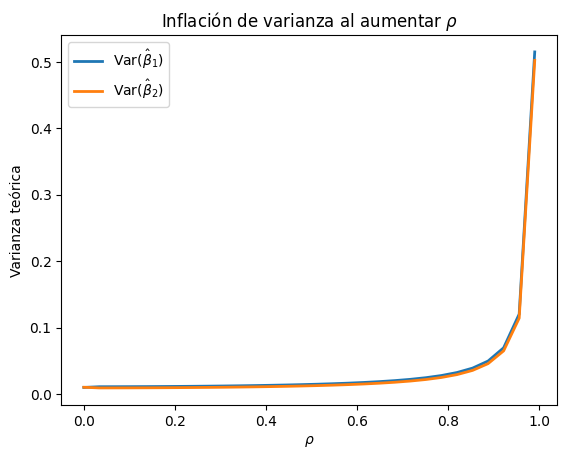

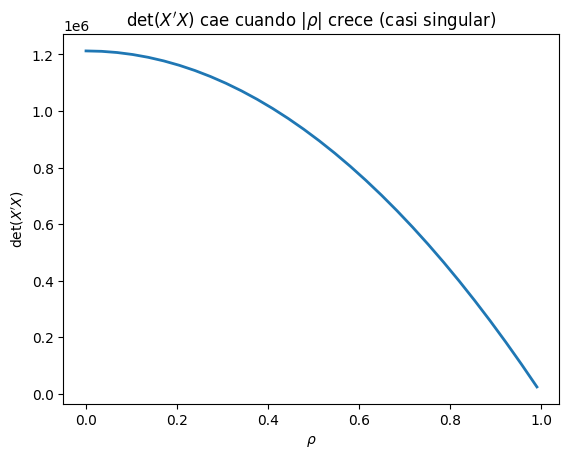

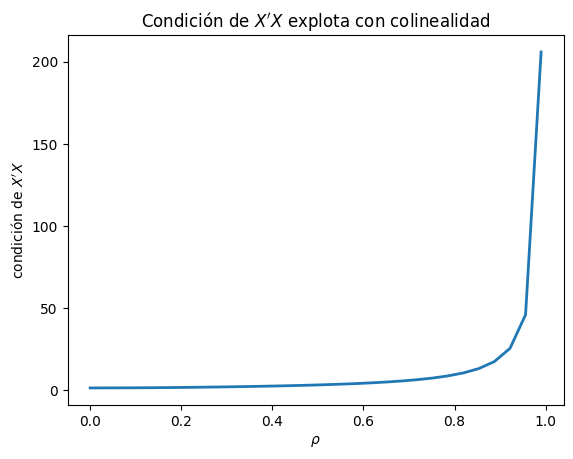

In [10]:
# @title
# ==========================================================
# Verlo en vivo: rho vs Var(beta_hat) y det(X'X)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

def design_matrix(n, rho, seed=0, center=True):
    rng = np.random.default_rng(seed)
    cov = np.array([[1.0, rho],[rho, 1.0]])
    X12 = rng.multivariate_normal([0.0, 0.0], cov, size=n)
    x1, x2 = X12[:,0], X12[:,1]
    if center:
        x1 = x1 - x1.mean()
        x2 = x2 - x2.mean()
    X = np.column_stack([np.ones(n), x1, x2])
    return X

def sweep_rho(n=120, sigma=1.0, seed=0, center=True):
    rhos = np.linspace(0.0, 0.99, 30)
    var_b1 = []
    var_b2 = []
    det_xtx = []
    cond_xtx = []

    for rho in rhos:
        X = design_matrix(n, rho, seed=seed, center=center)
        XtX = X.T @ X
        XtX_inv = np.linalg.inv(XtX)

        V = sigma**2 * XtX_inv  # Var-Cov teórica

        var_b1.append(V[1,1])
        var_b2.append(V[2,2])
        det_xtx.append(np.linalg.det(XtX))
        cond_xtx.append(np.linalg.cond(XtX))  # condición numérica

    # Plot 1: Varianzas vs rho
    plt.figure()
    plt.plot(rhos, var_b1, linewidth=2, label=r"$\mathrm{Var}(\hat\beta_1)$")
    plt.plot(rhos, var_b2, linewidth=2, label=r"$\mathrm{Var}(\hat\beta_2)$")
    plt.xlabel(r"$\rho$")
    plt.ylabel("Varianza teórica")
    plt.title(r"Inflación de varianza al aumentar $\rho$")
    plt.legend()
    plt.show()

    # Plot 2: det(X'X) vs rho (tiende a 0)
    plt.figure()
    plt.plot(rhos, det_xtx, linewidth=2)
    plt.xlabel(r"$\rho$")
    plt.ylabel(r"$\det(X'X)$")
    plt.title(r"$\det(X'X)$ cae cuando $|\rho|$ crece (casi singular)")
    plt.show()

    # Plot 3: condición vs rho (explota)
    plt.figure()
    plt.plot(rhos, cond_xtx, linewidth=2)
    plt.xlabel(r"$\rho$")
    plt.ylabel(r"condición de $X'X$")
    plt.title(r"Condición de $X'X$ explota con colinealidad")
    plt.show()

sweep_rho(n=120, sigma=1.0, seed=1, center=True)


In [11]:
# @title
# ============================================================
# Distribución de \hat{beta} en regresión lineal (interactivo)
# ============================================================

# (1) Imports base
import numpy as np
import matplotlib.pyplot as plt

# (2) Colab: habilitar widgets (importante)
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

# (3) Widgets: imports robustos
try:
    import ipywidgets as widgets
    from ipywidgets import interact
    from ipywidgets.widgets import IntSlider, FloatSlider, Dropdown, Checkbox
except Exception:
    !pip -q install ipywidgets
    import ipywidgets as widgets
    from ipywidgets import interact
    from ipywidgets.widgets import IntSlider, FloatSlider, Dropdown, Checkbox


# ============================================================
# Simulación
# ============================================================
def simulate_betas(n=80, sigma=1.0, rho=0.3, R=2000, seed=123, center=True):
    """
    Simula R réplicas de hat{beta} en el modelo:
        y = b0 + b1 x1 + b2 x2 + eps,  eps ~ N(0, sigma^2)

    x1, x2 ~ Normal bivariada con corr = rho.
    Si center=True, centra x1, x2 (media cero).
    """
    rng = np.random.default_rng(seed)

    beta = np.array([1.0, 2.0, -1.5])  # (b0, b1, b2)

    # X1, X2 con correlación rho
    cov = np.array([[1.0, rho], [rho, 1.0]])
    X12 = rng.multivariate_normal(mean=[0.0, 0.0], cov=cov, size=n)
    x1 = X12[:, 0]
    x2 = X12[:, 1]

    if center:
        x1 = x1 - x1.mean()
        x2 = x2 - x2.mean()

    X = np.column_stack([np.ones(n), x1, x2])

    # (X'X)^-1 y var teórica de \hat{beta} | X
    XtX = X.T @ X
    XtX_inv = np.linalg.inv(XtX)
    V_theory = (sigma**2) * XtX_inv

    # Simular R veces
    betas_hat = np.empty((R, 3), float)
    for r in range(R):
        eps = rng.normal(0.0, sigma, size=n)
        y = X @ beta + eps
        bhat = XtX_inv @ (X.T @ y)
        betas_hat[r, :] = bhat

    return beta, betas_hat, V_theory, X


def demo(n=80, sigma=1.0, rho=0.3, R=2000, seed=123, param="b1", bins=40,
         show_normal=True, show_naive=True, center_X=True):
    beta, betas_hat, V_theory, X = simulate_betas(
        n=n, sigma=sigma, rho=rho, R=R, seed=seed, center=center_X
    )

    idx = {"b0": 0, "b1": 1, "b2": 2}[param]
    vals = betas_hat[:, idx]
    mu = float(beta[idx])
    var_true = float(V_theory[idx, idx])
    sd_true = float(np.sqrt(var_true))

    # "naive" var = sigma^2/n (solo contraste didáctico)
    var_naive = float(sigma**2 / n)
    sd_naive = float(np.sqrt(var_naive))

    # Histograma
    plt.figure(figsize=(8, 4))
    plt.hist(vals, bins=bins, density=True, alpha=0.75)

    xs = np.linspace(vals.min(), vals.max(), 400)

    # Curva normal teórica (aprox condicional a X)
    if show_normal:
        pdf_true = (1 / (sd_true * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sd_true) ** 2)
        plt.plot(xs, pdf_true, linewidth=2, label="Normal teórica (Var=(σ²)(X'X)⁻¹)")

    # Curva "naive"
    if show_naive:
        pdf_naive = (1 / (sd_naive * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sd_naive) ** 2)
        plt.plot(xs, pdf_naive, linewidth=2, label="Naive (Var=σ²/n)")

    plt.axvline(mu, linestyle="--", linewidth=1)

    # Importante: LaTeX en raw f-string para evitar warnings/escapes
    plt.title(rf"Distribución muestral de $\hat{{\beta}}$ ({param}) — R={R}")
    plt.xlabel(rf"$\hat{{\beta}}$ ({param})")
    plt.ylabel("densidad")
    plt.legend()
    plt.show()

    # Resumen numérico (conciso)
    print(f"Media empírica: {vals.mean():.4f}    |    Media teórica: {mu:.4f}")
    print(f"Var empírica:   {vals.var(ddof=1):.4f}")
    print(f"Var teórica:    {var_true:.4f}")
    print(rf"Var 'naive' $\sigma^2/n$: {var_naive:.4f}")

    # Mostrar el elemento diagonal de (X'X)^-1 (para ver el efecto de colinealidad)
    XtX_inv = np.linalg.inv(X.T @ X)
    print(r"Diag de $(X'X)^{-1}$ para este parámetro:", float(XtX_inv[idx, idx]))


# ============================================================
# Interactivo
# ============================================================
interact(
    demo,
    n=IntSlider(80, min=20, max=400, step=10, description="n"),
    sigma=FloatSlider(1.0, min=0.2, max=5.0, step=0.1, description="sigma"),
    rho=FloatSlider(0.3, min=-0.99, max=0.99, step=0.05, description="rho"),
    R=IntSlider(2000, min=200, max=10000, step=200, description="R"),
    seed=IntSlider(123, min=0, max=999, step=1, description="seed"),
    param=Dropdown(options=["b0", "b1", "b2"], value="b1", description="param"),
    bins=IntSlider(40, min=10, max=120, step=5, description="bins"),
    show_normal=Checkbox(True, description="Normal teórica"),
    show_naive=Checkbox(True, description="Mostrar sigma^2/n"),
    center_X=Checkbox(True, description="Centrar X1,X2"),
);


interactive(children=(IntSlider(value=80, description='n', max=400, min=20, step=10), FloatSlider(value=1.0, d…